<a href="https://colab.research.google.com/github/changsin/polysemy_xlang_wsi/blob/main/notebooks/polysemy_robustness_checks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robustness Checks

## 5.2 Robustness check

This section of the notebook performs a **robustness check** to ensure that the observed differences in polysemy between English and Chinese lemmas are not an artifact of comparing potentially dissimilar sets of words.

Here's what the robustness check entails:

1.  **Identifying Co-occurrence Pairs**: The first step is to identify "lemma co-occurrence pairs". These are pairs of English and Chinese lemmas that appear together in the same 'verse_id' (e.g., the same biblical verse). For instance, if the English lemma 'love' and the Chinese lemma '爱' (ài) both appear in verse John 3:16, they form a co-occurrence pair for that verse.

2.  **Counting Co-occurrences**: The code then counts how many times each unique (English lemma, Chinese lemma) pair co-occurs across all verses. This gives a measure of how strongly associated these cross-lingual lemma pairs are.

3.  **Filtering for Strong Overlaps**: To focus on robust comparisons, only pairs that co-occur at least 10 times are retained. These are considered "strong overlaps" and form the basis for the subsequent analysis.

4.  **Restricting WSI Results**: The next step restricts the Word Sense Induction (WSI) results for both English and Chinese to include *only* those lemmas that participated in these strong co-occurrence pairs. This ensures that the comparison is made on a set of lemmas that have clear cross-lingual counterparts.

5.  **Re-running Statistical Tests**: Finally, the Mann-Whitney U test and the frequency-stratified comparison (which were previously run on the full sets of lemmas) are re-executed, but this time only on the filtered sets of overlapping lemmas. This verifies if the significant differences in polysemy between English and Chinese persist even when controlling for cross-lingual co-occurrence.

In essence, the robustness check aims to strengthen the confidence in the findings by ensuring they hold under more stringent comparison conditions, specifically by focusing on lemmas that are directly comparable across languages due to their shared textual context.

## 5.2.0 Load data

Upload the following files under `bible_data`:
- enlgish_wsi_results.csv
- chinese_wsi_results.csv
- english_sense_labels.csv
- chinese_sense_labels.csv
- english_embeddings.npz
- chinese_embeddings.npz

In [ ]:
import pandas as pd
from pathlib import Path
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Load the WSI results for English and Chinese, if not already loaded
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

### 5.2.1 Build lemma co-occurence pairs

In [ ]:
print("\n" + "="*60)
print("Step 8: Overlap-Only Robustness Check")
print("="*60)

# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

# Merge on verse_id to get co-occurring lemmas
merged = en_labels.merge(
    zh_labels,
    on="verse_id",
    suffixes=("_en", "_zh")
)

# Count lemma co-occurrence pairs
pair_counts = (
    merged.groupby(["lemma_en", "lemma_zh"])
    .size()
    .reset_index(name="co_occurrences")
)

# Keep only strong overlaps (at least 10 shared verses)
pair_counts = pair_counts[pair_counts["co_occurrences"] >= 10]

print(f"Total aligned lemma pairs: {len(pair_counts)}")


Step 8: Overlap-Only Robustness Check
Total aligned lemma pairs: 4689


### 5.2.2 Identify overlapping lemma sets

In [ ]:
# Lemmas that participate in aligned pairs
en_overlap = set(pair_counts["lemma_en"])
zh_overlap = set(pair_counts["lemma_zh"])

print(f"English overlapping lemmas: {len(en_overlap)}")
print(f"Chinese overlapping lemmas: {len(zh_overlap)}")

English overlapping lemmas: 595
Chinese overlapping lemmas: 473


5.2.3 Restrict WSI results to overlap lemmas only

In [ ]:
en_overlap_df = en[en["lemma"].isin(en_overlap)]
zh_overlap_df = zh[zh["lemma"].isin(zh_overlap)]

print(f"Filtered EN lemmas: {len(en_overlap_df)}")
print(f"Filtered ZH lemmas: {len(zh_overlap_df)}")

Filtered EN lemmas: 595
Filtered ZH lemmas: 473


### 5.2.4 Run Mann-Whitney on overlap only

In [ ]:
from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(
    en_overlap_df["k_hdbscan"],
    zh_overlap_df["k_hdbscan"],
    alternative="two-sided"
)

print("\n── Overlap-Only Statistical Comparison ──")
print(f"EN mean k: {en_overlap_df['k_hdbscan'].mean():.3f}")
print(f"ZH mean k: {zh_overlap_df['k_hdbscan'].mean():.3f}")
print(f"p-value: {p:.6f}")


── Overlap-Only Statistical Comparison ──
EN mean k: 1.926
ZH mean k: 1.237
p-value: 0.000000


In [ ]:
print("\n" + "="*60)
print("Frequency-Matched Polysemy Comparison (Overlap Only)")
print("="*60)

# Define bins
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Assign bins to overlap dataframes directly
en_overlap_df = en_overlap_df.copy()
zh_overlap_df = zh_overlap_df.copy()

en_overlap_df["freq_bin"] = en_overlap_df["n_instances"].apply(assign_bin)
zh_overlap_df["freq_bin"] = zh_overlap_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_overlap_df = en_overlap_df.dropna(subset=["freq_bin"])
zh_bin_overlap_df = zh_overlap_df.dropna(subset=["freq_bin"])

bin_results = []

for bin_label in labels:
    en_subset = en_bin_overlap_df[
        en_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_overlap_df[
        zh_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    from scipy.stats import mannwhitneyu
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_df = pd.DataFrame(bin_results)

print("\n── Frequency-Stratified Results (Overlap Only) ──")
print(bin_df)

bin_df.to_csv(
    OUTPUT_DIR / "frequency_matched_comparison_overlap_df.csv",
    index=False
)


Frequency-Matched Polysemy Comparison (Overlap Only)

── Frequency-Stratified Results (Overlap Only) ──
  freq_bin  en_mean_k  zh_mean_k  n_en  n_zh       p_value
0    30–59   1.502370   1.100000   211   200  1.253895e-16
1    60–99   1.813793   1.264463   145   121  6.957939e-12
2  100–199   1.984848   1.348837   132    86  6.848508e-09
3  200–499   2.760000   1.460000    75    50  8.011587e-07
4     500+   3.031250   1.437500    32    16  2.476788e-05


In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("\n" + "="*60)
print("Frequency-Matched Polysemy Comparison (All Nouns)")
print("="*60)

# Define bins (copy from previous cell)
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Load the WSI results for English and Chinese, if not already loaded (to ensure we use full data)
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Assign bins to the full dataframes
en_all_df = en.copy()
zh_all_df = zh.copy()

en_all_df["freq_bin"] = en_all_df["n_instances"].apply(assign_bin)
zh_all_df["freq_bin"] = zh_all_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_all_df = en_all_df.dropna(subset=["freq_bin"])
zh_bin_all_df = zh_all_df.dropna(subset=["freq_bin"])

bin_results_all = []

for bin_label in labels:
    en_subset = en_bin_all_df[
        en_bin_all_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_all_df[
        zh_bin_all_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    from scipy.stats import mannwhitneyu
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results_all.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_all_df = pd.DataFrame(bin_results_all)

print("\n── Frequency-Stratified Results (All Nouns) ──")
print(bin_all_df)

bin_all_df.to_csv(
    OUTPUT_DIR / "frequency_matched_comparison_all_nouns_df.csv",
    index=False
)



Frequency-Matched Polysemy Comparison (All Nouns)

── Frequency-Stratified Results (All Nouns) ──
  freq_bin  en_mean_k  zh_mean_k  n_en  n_zh       p_value
0    30–59   1.472222   1.095890   252   219  1.368113e-16
1    60–99   1.813793   1.264000   145   125  4.169471e-12
2  100–199   1.984848   1.348837   132    86  6.848508e-09
3  200–499   2.760000   1.460000    75    50  8.011587e-07
4     500+   3.031250   1.437500    32    16  2.476788e-05


In [ ]:
import pandas as pd

# Assuming en_bin_overlap_df, zh_bin_overlap_df, en_bin_all_df, zh_bin_all_df, and labels are already defined
# If not, the preceding cells that define these would need to be run.

monosemous_results = []

for bin_label in labels:
    # Overlap Only
    en_subset_overlap = en_bin_overlap_df[en_bin_overlap_df["freq_bin"] == bin_label]
    zh_subset_overlap = zh_bin_overlap_df[zh_bin_overlap_df["freq_bin"] == bin_label]

    n_en_overlap = len(en_subset_overlap)
    n_zh_overlap = len(zh_subset_overlap)

    monosemous_en_overlap = len(en_subset_overlap[en_subset_overlap["k_hdbscan"] == 1])
    monosemous_zh_overlap = len(zh_subset_overlap[zh_subset_overlap["k_hdbscan"] == 1])

    perc_monosemous_en_overlap = (monosemous_en_overlap / n_en_overlap * 100) if n_en_overlap > 0 else 0
    perc_monosemous_zh_overlap = (monosemous_zh_overlap / n_zh_overlap * 100) if n_zh_overlap > 0 else 0

    # All Nouns
    en_subset_all = en_bin_all_df[en_bin_all_df["freq_bin"] == bin_label]
    zh_subset_all = zh_bin_all_df[zh_bin_all_df["freq_bin"] == bin_label]

    n_en_all = len(en_subset_all)
    n_zh_all = len(zh_subset_all)

    monosemous_en_all = len(en_subset_all[en_subset_all["k_hdbscan"] == 1])
    monosemous_zh_all = len(zh_subset_all[zh_subset_all["k_hdbscan"] == 1])

    perc_monosemous_en_all = (monosemous_en_all / n_en_all * 100) if n_en_all > 0 else 0
    perc_monosemous_zh_all = (monosemous_zh_all / n_zh_all * 100) if n_zh_all > 0 else 0

    monosemous_results.append({
        "freq_bin": bin_label,
        "% Monosemous EN (Overlap)": perc_monosemous_en_overlap,
        "% Monosemous ZH (Overlap)": perc_monosemous_zh_overlap,
        "Monosemous Count EN (Overlap)": monosemous_en_overlap,
        "Monosemous Count ZH (Overlap)": monosemous_zh_overlap,
        "N EN (Overlap)": n_en_overlap,
        "N ZH (Overlap)": n_zh_overlap,
        "% Monosemous EN (All)": perc_monosemous_en_all,
        "% Monosemous ZH (All)": perc_monosemous_zh_all,
        "Monosemous Count EN (All)": monosemous_en_all,
        "Monosemous Count ZH (All)": monosemous_zh_all,
        "N EN (All)": n_en_all,
        "N ZH (All)": n_zh_all
    })

monosemous_df = pd.DataFrame(monosemous_results)

print("\n── Percentage of Monosemous Words by Frequency Bin ──")
display(monosemous_df.round(2))


── Percentage of Monosemous Words by Frequency Bin ──


,freq_bin,% Monosemous EN (Overlap),% Monosemous ZH (Overlap),Monosemous Count EN (Overlap),Monosemous Count ZH (Overlap),N EN (Overlap),N ZH (Overlap),% Monosemous EN (All),% Monosemous ZH (All),Monosemous Count EN (All),Monosemous Count ZH (All),N EN (All),N ZH (All)
0,30–59,53.08,90.00,112,180,211,200,56.35,90.41,142,198,252,219
1,60–99,33.79,75.21,49,91,145,121,33.79,75.20,49,94,145,125
2,100–199,34.85,75.58,46,65,132,86,34.85,75.58,46,65,132,86
3,200–499,28.00,70.00,21,35,75,50,28.00,70.00,21,35,75,50
4,500+,9.38,56.25,3,9,32,16,9.38,56.25,3,9,32,16


In [ ]:
# Define the mid-frequency bins
mid_freq_bins = ["100–199", "200–499"]

# Filter English data for mid-frequency bins
en_mid_freq = en_bin_all_df[en_bin_all_df["freq_bin"].isin(mid_freq_bins)]

# Filter Chinese data for mid-frequency bins
zh_mid_freq = zh_bin_all_df[zh_bin_all_df["freq_bin"].isin(mid_freq_bins)]

# Count lemmas with k_hdbscan >= 4 for English
en_k_ge_4 = en_mid_freq[en_mid_freq["k_hdbscan"] >= 4]
count_en_k_ge_4 = len(en_k_ge_4)

# Count lemmas with k_hdbscan >= 4 for Chinese
zh_k_ge_4 = zh_mid_freq[zh_mid_freq["k_hdbscan"] >= 4]
count_zh_k_ge_4 = len(zh_k_ge_4)

print(f"\n── Mid-Frequency Lemmas (100-499 Instances) with k >= 4 ──")
print(f"English: {count_en_k_ge_4} lemmas")
print(f"Chinese: {count_zh_k_ge_4} lemmas")

print("\nEnglish lemmas with k >= 4:")
if not en_k_ge_4.empty:
    display(en_k_ge_4[['lemma', 'n_instances', 'k_hdbscan']].sort_values(by='k_hdbscan', ascending=False))
else:
    print("No English lemmas found with k >= 4 in this frequency range.")

print("\nChinese lemmas with k >= 4:")
if not zh_k_ge_4.empty:
    display(zh_k_ge_4[['lemma', 'n_instances', 'k_hdbscan']].sort_values(by='k_hdbscan', ascending=False))
else:
    print("No Chinese lemmas found with k >= 4 in this frequency range.")


── Mid-Frequency Lemmas (100-499 Instances) with k >= 4 ──
English: 34 lemmas
Chinese: 4 lemmas

English lemmas with k >= 4:


,lemma,n_instances,k_hdbscan
169,end,307,9
89,clan,276,9
294,lamb,151,6
625,work,373,6
222,gate,265,6
208,foot,362,6
488,shekel,145,6
343,mother,336,6
340,month,264,5
13,anger,260,5



Chinese lemmas with k >= 4:


,lemma,n_instances,k_hdbscan
131,子孫,429,5
388,舍客勒,128,5
441,郊野,117,5
319,祭,112,4


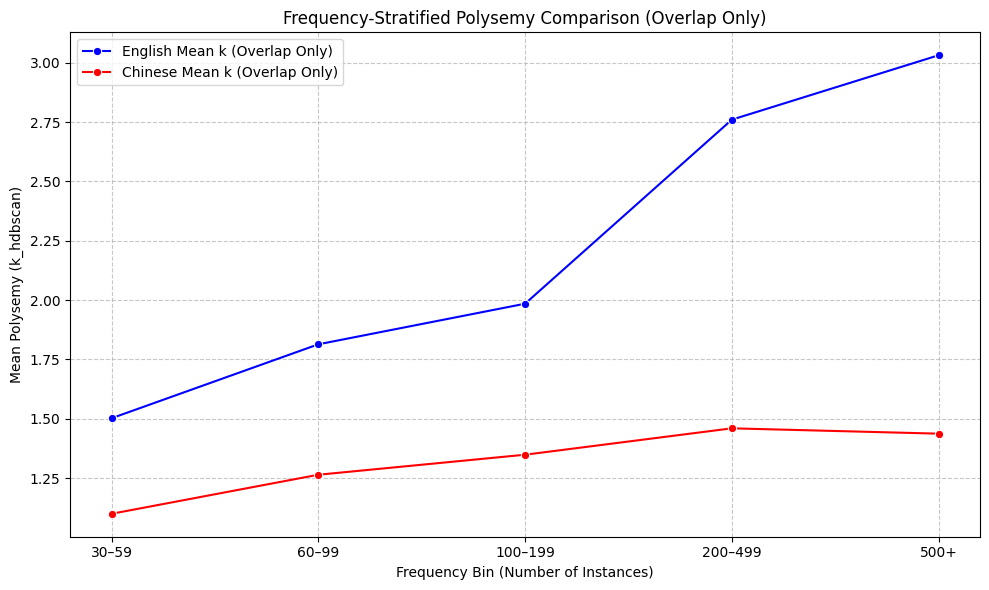

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu # Needed for bin_df calculation
import numpy as np # Needed for bin_df calculation if not already imported

# Define DATA_DIR and OUTPUT_DIR for this cell
DATA_DIR = Path("/content") / "bible_data"
OUTPUT_DIR = Path("/content") / "output"
FIG_DIR    = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Re-calculate bin_df (from previous cells: LXgPj1knDfH, E216lrC8naUB, sQC1rwEhnn-d, LE16SdJXoE-X)
# Load per-instance sense labels
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")
zh_labels = pd.read_csv(DATA_DIR / "chinese_sense_labels.csv")

# Merge on verse_id to get co-occurring lemmas
merged = en_labels.merge(
    zh_labels,
    on="verse_id",
    suffixes=("_en", "_zh")
)

# Count lemma co-occurrence pairs
pair_counts = (
    merged.groupby(["lemma_en", "lemma_zh"])
    .size()
    .reset_index(name="co_occurrences")
)

# Keep only strong overlaps (at least 10 shared verses)
pair_counts = pair_counts[pair_counts["co_occurrences"] >= 10]

# Lemmas that participate in aligned pairs
en_overlap = set(pair_counts["lemma_en"])
zh_overlap = set(pair_counts["lemma_zh"])

# Load WSI results (assuming 'en' and 'zh' from W2ciQBzRtimn are in scope, but better to load locally)
en_wsi = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh_wsi = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Restrict WSI results to overlap lemmas only
en_overlap_df = en_wsi[en_wsi["lemma"].isin(en_overlap)]
zh_overlap_df = zh_wsi[zh_wsi["lemma"].isin(zh_overlap)]

# Define bins for frequency stratification
bins = [30, 60, 100, 200, 500, 1000]
labels = ["30–59", "60–99", "100–199", "200–499", "500+"]

def assign_bin(n):
    for i in range(len(bins)-1):
        if bins[i] <= n < bins[i+1]:
            return labels[i]
    if n >= bins[-1]:
        return labels[-1]
    return None

# Assign bins to overlap dataframes
en_overlap_df = en_overlap_df.copy() # Avoid SettingWithCopyWarning
zh_overlap_df = zh_overlap_df.copy() # Avoid SettingWithCopyWarning

en_overlap_df["freq_bin"] = en_overlap_df["n_instances"].apply(assign_bin)
zh_overlap_df["freq_bin"] = zh_overlap_df["n_instances"].apply(assign_bin)

# Remove words outside bins
en_bin_overlap_df = en_overlap_df.dropna(subset=["freq_bin"])
zh_bin_overlap_df = zh_overlap_df.dropna(subset=["freq_bin"])

bin_results = []

for bin_label in labels:
    en_subset = en_bin_overlap_df[
        en_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    zh_subset = zh_bin_overlap_df[
        zh_bin_overlap_df["freq_bin"] == bin_label
    ]["k_hdbscan"]

    if len(en_subset) < 5 or len(zh_subset) < 5:
        continue

    # mannwhitneyu imported above
    U, p = mannwhitneyu(en_subset, zh_subset, alternative="two-sided")

    bin_results.append({
        "freq_bin": bin_label,
        "en_mean_k": en_subset.mean(),
        "zh_mean_k": zh_subset.mean(),
        "n_en": len(en_subset),
        "n_zh": len(zh_subset),
        "p_value": p
    })

bin_df = pd.DataFrame(bin_results)

# Now the plotting code
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='freq_bin',
    y='en_mean_k',
    data=bin_df,
    marker='o',
    label='English Mean k (Overlap Only)',
    color='blue'
)
sns.lineplot(
    x='freq_bin',
    y='zh_mean_k',
    data=bin_df,
    marker='o',
    label='Chinese Mean k (Overlap Only)',
    color='red'
)

plt.title('Frequency-Stratified Polysemy Comparison (Overlap Only)')
plt.xlabel('Frequency Bin (Number of Instances)')
plt.ylabel('Mean Polysemy (k_hdbscan)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

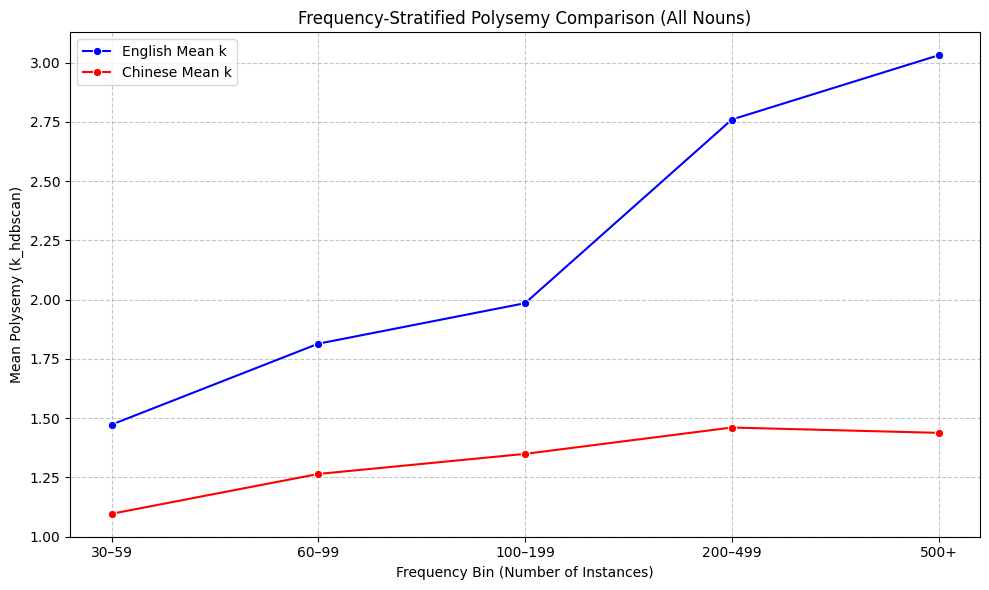

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure bin_all_df is sorted by frequency bin for correct plotting
# The current labels are already ordered, so direct plotting should work.

plt.figure(figsize=(10, 6))
sns.lineplot(
    x='freq_bin',
    y='en_mean_k',
    data=bin_all_df,
    marker='o',
    label='English Mean k',
    color='blue'
)
sns.lineplot(
    x='freq_bin',
    y='zh_mean_k',
    data=bin_all_df,
    marker='o',
    label='Chinese Mean k',
    color='red'
)

plt.title('Frequency-Stratified Polysemy Comparison (All Nouns)')
plt.xlabel('Frequency Bin (Number of Instances)')
plt.ylabel('Mean Polysemy (k_hdbscan)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 5.3 Bootstrap Stability

In [ ]:
RANDOM_STATE  = 42

# The threshold to do PCA reduction
LARGE_SAMPLE_SIZE = 200
# Max number of components to keep for PCA
COMPONENTS_UPPPER_LIMIT = 100

# HDBSCAN specific constants
# minimum number of datapoints to be considered as a cluster
MIN_CLUSTER_DATA_SIZE = 6
# minimum percentage of datapoints with respect to the total datapoints
MIN_CLUSTER_DATA_PROPORTION = 0.03
# If the second largest cluster is below this proportion, count as monosemous
SECOND_CLUSTER_THRESHOLD = 0.08

# ─── HDBSCAN ──────────────────────────────────────────────

import hdbscan
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize


def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    # too conservative
    # min_cluster_size = max(8, int(0.05 * n_samples))
    # More liberal parameters  3% instead of 5%
    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))


    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    # Use the configurable variable
    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels

### 5.3.1 Bootstrap function

In [ ]:
import numpy as np
from collections import Counter

def bootstrap_k(embeddings, n_runs=20, sample_ratio=0.8):
    """
    Bootstrap stability for a single lemma.

    Returns:
        mode_k     : most frequent induced k across runs
        stability  : proportion of runs equal to mode_k
        all_ks     : list of k from each run
    """
    n = len(embeddings)

    if n < 20:
        return 1, 1.0, [1]

    ks = []

    for _ in range(n_runs):
        sample_size = int(sample_ratio * n)
        idx = np.random.choice(n, sample_size, replace=False)
        subset = embeddings[idx]

        k, _ = induce_senses_hdbscan(subset)
        ks.append(k)

    counter = Counter(ks)
    mode_k = counter.most_common(1)[0][0]
    stability = counter[mode_k] / n_runs

    return mode_k, stability, ks

### 5.3.2 Run Bootstrap for Entire Language

In [ ]:
def run_bootstrap_for_language(lang: str, n_runs=20):
    print(f"\n[{lang.upper()}] Running bootstrap stability...")

    embeddings_file = DATA_DIR / f"{lang}_embeddings.npz"
    results_file = DATA_DIR / f"{lang}_wsi_results.csv"

    data = np.load(embeddings_file, allow_pickle=True)
    lemmas_array = data["lemmas"]
    embeddings = data["embeddings"]

    df = pd.read_csv(results_file)

    stability_records = []

    unique_lemmas = df["lemma"].values

    for i, lemma in enumerate(unique_lemmas):
        mask = (lemmas_array == lemma)
        lemma_embeds = embeddings[mask]

        mode_k, stability, ks = bootstrap_k(
            lemma_embeds,
            n_runs=n_runs,
            sample_ratio=0.8
        )

        stability_records.append({
            "lemma": lemma,
            "n_instances": len(lemma_embeds),
            "k_bootstrap_mode": mode_k,
            "stability": stability
        })

        if (i + 1) % 50 == 0 or (i + 1) == len(unique_lemmas):
            print(f"  {i+1}/{len(unique_lemmas)} lemmas", end="\r")

    stability_df = pd.DataFrame(stability_records)

    out_path = DATA_DIR / f"{lang}_bootstrap_stability.csv"
    stability_df.to_csv(out_path, index=False)

    print(f"\n[{lang.upper()}] Saved bootstrap results → {out_path.name}")

    return stability_df

### 5.3.3 Run for both languages

In [ ]:
en_boot = run_bootstrap_for_language("english", n_runs=20)
zh_boot = run_bootstrap_for_language("chinese", n_runs=20)


[ENGLISH] Running bootstrap stability...
  636/636 lemmas
[ENGLISH] Saved bootstrap results → english_bootstrap_stability.csv

[CHINESE] Running bootstrap stability...
  496/496 lemmas
[CHINESE] Saved bootstrap results → chinese_bootstrap_stability.csv


### 5.3.4 Compare stability across languages

In [ ]:
print("\n" + "="*60)
print("Bootstrap Stability Comparison")
print("="*60)

print(f"EN mean stability: {en_boot['stability'].mean():.3f}")
print(f"ZH mean stability: {zh_boot['stability'].mean():.3f}")

from scipy.stats import mannwhitneyu

U, p = mannwhitneyu(
    en_boot["stability"],
    zh_boot["stability"],
    alternative="two-sided"
)

print(f"Stability difference p-value: {p:.6f}")


Bootstrap Stability Comparison
EN mean stability: 0.872
ZH mean stability: 0.943
Stability difference p-value: 0.000000


### 5.3.5 Compare stability for polysemous lemmas only

In [ ]:
en_poly = en_boot[en_boot["k_bootstrap_mode"] > 1]
zh_poly = zh_boot[zh_boot["k_bootstrap_mode"] > 1]

print("\nPolysemous-only stability:")
print(f"EN mean stability: {en_poly['stability'].mean():.3f}")
print(f"ZH mean stability: {zh_poly['stability'].mean():.3f}")

U_poly, p_poly = mannwhitneyu(
    en_poly["stability"],
    zh_poly["stability"],
    alternative="two-sided"
)

print(f"Polysemous stability p-value: {p_poly:.6f}")


Polysemous-only stability:
EN mean stability: 0.841
ZH mean stability: 0.799
Polysemous stability p-value: 0.123057


## 5.4 Regression Model

### 5.4.1 Merge and Prepare Data

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path

# Ensure 'en' and 'zh' DataFrames are available.
DATA_DIR = Path("/content") / "bible_data"
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Add language label
en["language"] = 1   # English
zh["language"] = 0   # Chinese

# Combine
df = pd.concat([en, zh], ignore_index=True)

# Log frequency
df["log_freq"] = np.log(df["n_instances"])

# Response variable
df["k"] = df["k_hdbscan"]

### 5.4.2 Poisson Regression

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from pathlib import Path

# Ensure 'en' and 'zh' DataFrames are available.
DATA_DIR = Path("/content") / "bible_data"
en = pd.read_csv(DATA_DIR / "english_wsi_results.csv")
zh = pd.read_csv(DATA_DIR / "chinese_wsi_results.csv")

# Add language label
en["language"] = 1   # English
zh["language"] = 0   # Chinese

# Combine
df = pd.concat([en, zh], ignore_index=True)

# Log frequency
df["log_freq"] = np.log(df["n_instances"])

# Response variable
df["k"] = df["k_hdbscan"]

poisson_model = smf.glm(
    formula="k ~ language + log_freq",
    data=df,
    family=sm.families.Poisson()
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      k   No. Observations:                 1132
Model:                            GLM   Df Residuals:                     1129
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1480.9
Date:                Thu, 19 Mar 2026   Deviance:                       343.25
Time:                        15:09:59   Pearson chi2:                     392.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.1208
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7253      0.118     -6.170      0.0

### 5.4.3 Check for Overdispersion

In [ ]:
mean_k = df["k"].mean()
var_k = df["k"].var()

print("Mean k:", mean_k)
print("Variance k:", var_k)

Mean k: 1.598939929328622
Variance k: 0.884101439359136


### 5.4.4 Negative Binomial Regression

In [ ]:
nb_model = smf.glm(
    formula="k ~ language + log_freq",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      k   No. Observations:                 1132
Model:                            GLM   Df Residuals:                     1129
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1933.3
Date:                Thu, 19 Mar 2026   Deviance:                       116.03
Time:                        15:09:59   Pearson chi2:                     139.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04674
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7306      0.200     -3.650      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


### 5.4.5 Interpret Language Coefficient

In [ ]:
beta_lang = nb_model.params["language"]
p_lang = nb_model.pvalues["language"]

print("Language coefficient:", beta_lang)
print("p-value:", p_lang)

# Incidence Rate Ratio
irr = np.exp(beta_lang)
print("Incidence Rate Ratio (English vs Chinese):", irr)

Language coefficient: 0.38596900163734227
p-value: 8.161273421614853e-07
Incidence Rate Ratio (English vs Chinese): 1.4710390703053913


### 5.4.6 Visualization

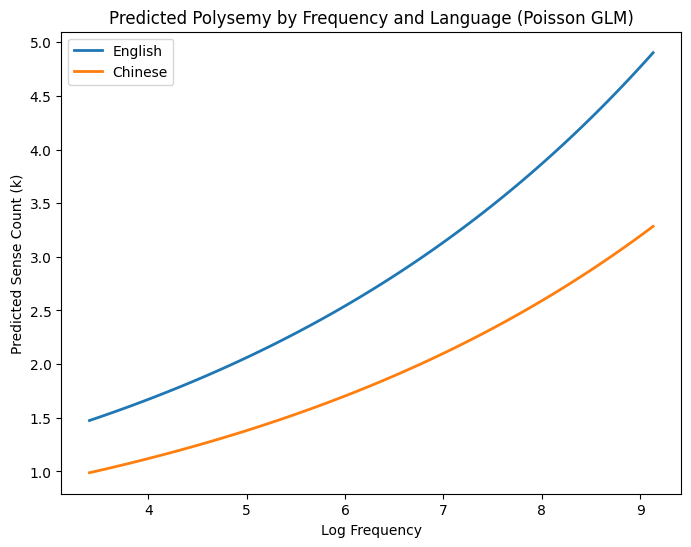

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create frequency range
freq_range = np.linspace(df["log_freq"].min(), df["log_freq"].max(), 100)

# Create prediction dataframe
pred_df_en = pd.DataFrame({
    "language": 1,
    "log_freq": freq_range
})

pred_df_zh = pd.DataFrame({
    "language": 0,
    "log_freq": freq_range
})

# Predict expected k
pred_en = poisson_model.predict(pred_df_en)
pred_zh = poisson_model.predict(pred_df_zh)

# Plot
plt.figure(figsize=(8,6))
plt.plot(freq_range, pred_en, label="English", linewidth=2)
plt.plot(freq_range, pred_zh, label="Chinese", linewidth=2)
plt.xlabel("Log Frequency")
plt.ylabel("Predicted Sense Count (k)")
plt.title("Predicted Polysemy by Frequency and Language (Poisson GLM)")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from pathlib import Path

# Assuming DATA_DIR, en, zh, en_labels, zh_labels are already defined from previous cells.
# Re-initializing DATA_DIR and loading verse files to make this cell self-contained if run out of order.
DATA_DIR = Path("/content") / "bible_data"

# Load verse content (ensure these are loaded for both languages)
en_verses = pd.read_csv(DATA_DIR / "english_verses.csv")
zh_verses = pd.read_csv(DATA_DIR / "chinese_verses.csv")

def get_polysemy_output(lemma_name, language='english', num_verses_to_show=3):
    if language == 'english':
        wsi_df = en # en dataframe loaded from english_wsi_results.csv
        labels_df = en_labels # en_labels dataframe loaded from english_sense_labels.csv
        verse_content_df = en_verses # English verse content
    elif language == 'chinese':
        wsi_df = zh # zh dataframe loaded from chinese_wsi_results.csv
        labels_df = zh_labels # zh_labels dataframe loaded from chinese_sense_labels.csv
        verse_content_df = zh_verses # Chinese verse content
    else:
        print("Invalid language specified. Please choose 'english' or 'chinese'.")
        return

    # Get k and n for the lemma
    lemma_data = wsi_df[wsi_df['lemma'] == lemma_name]

    if lemma_data.empty:
        print(f"Lemma '{lemma_name}' not found in the {language} WSI results.")
        return

    k = lemma_data['k_hdbscan'].iloc[0]
    n = lemma_data['n_instances'].iloc[0]

    print(f"Lemma: '{lemma_name}'  |  k={k}  |  n={n}")
    print("--------------------------------------------------")

    # Get all instances for the lemma
    lemma_instances = labels_df[labels_df['lemma'] == lemma_name]

    # Group by cluster_hdbscan to find senses and their occurrences
    sense_counts = lemma_instances.groupby('cluster_hdbscan').size().sort_values(ascending=False)

    # Filter out noise cluster (-1) unless it's the only cluster
    senses_to_display = sense_counts[sense_counts.index != -1] if -1 in sense_counts.index and len(sense_counts) > 1 else sense_counts

    if senses_to_display.empty:
        print("  No distinct senses identified (or all instances are noise).")
        return

    for i, (cluster_id, count) in enumerate(senses_to_display.items()):
        sense_label = f"Sense {i + 1}"
        if cluster_id == -1:
            sense_label = "Noise Cluster (-1)"

        print(f"  {sense_label} ({count} occurrences):")

        # Get verse_ids for this sense
        sense_verse_ids = lemma_instances[
            lemma_instances['cluster_hdbscan'] == cluster_id
        ]['verse_id'].drop_duplicates().tolist()

        # Retrieve actual verse texts
        verses_for_sense = verse_content_df[verse_content_df['verse_id'].isin(sense_verse_ids)]

        # Display a sample of verses
        if not verses_for_sense.empty:
            for _, row in verses_for_sense.head(num_verses_to_show).iterrows():
                print(f"    • {row['verse_id']}: {row['text']}") # Corrected column name to 'text'
            if len(verses_for_sense) > num_verses_to_show:
                print(f"    ... (and {len(verses_for_sense) - num_verses_to_show} more verses)")
        else:
            print("    No verses found for this sense.")

# Example usage for 'servant' in English:
get_polysemy_output('servant', language='english')

# Example for another word, e.g., 'time':
# get_polysemy_output('time', language='english')

# Example for a Chinese word (replace with a known lemma from zh_wsi):
# get_polysemy_output('人', language='chinese') # '人' means 'person' or 'people' in Chinese

Lemma: 'servant'  |  k=2  |  n=767
--------------------------------------------------
  Sense 1 (484 occurrences):
    • Gen.15.3: And Abram said, "You have given me no children; so a servant in my household will be my heir."
    • Gen.16.5: Then Sarai said to Abram, "You are responsible for the wrong I am suffering. I put my servant in your arms, and now that she knows she is pregnant, she despises me. May the LORD judge between you and me."
    • Gen.16.6: "Your servant is in your hands," Abram said. "Do with her whatever you think best." Then Sarai mistreated Hagar; so she fled from her.
    ... (and 440 more verses)
  Sense 2 (266 occurrences):
    • Gen.21.25: Then Abraham complained to Abimelech about a well of water that Abimelech's servants had seized.
    • Gen.22.3: Early the next morning Abraham got up and saddled his donkey. He took with him two of his servants and his son Isaac. When he had cut enough wood for the burnt offering, he set out for the place God had told him a

In [ ]:
# Load per-instance sense labels (if not already loaded)
# en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv")

lemma_to_check = 'servant'
verse_to_check = 'Rev.1.1'

# Filter en_labels for the specific lemma and verse
rev_1_1_cluster = en_labels[
    (en_labels['lemma'] == lemma_to_check) &
    (en_labels['verse_id'] == verse_to_check)
]

if not rev_1_1_cluster.empty:
    cluster_id = rev_1_1_cluster['cluster_hdbscan'].iloc[0]
    print(f"The verse '{verse_to_check}' for lemma '{lemma_to_check}' belongs to cluster: {cluster_id}")
    if cluster_id == -1:
        print("This means it was classified as a noise point (not assigned to any clear cluster).")
    elif cluster_id == 0:
        print("This corresponds to Sense 1 (Personal/Domestic Attendant).")
    elif cluster_id == 1:
        print("This corresponds to Sense 2 (Member of a Retinue/Group of Subordinates).")
    else:
        print(f"This is an unhandled cluster ID: {cluster_id}")
else:
    print(f"The verse '{verse_to_check}' for lemma '{lemma_to_check}' was not found in the clustering results. It might not have met the frequency criteria for inclusion or was filtered out.")


The verse 'Rev.1.1' for lemma 'servant' belongs to cluster: 1
This corresponds to Sense 2 (Member of a Retinue/Group of Subordinates).


In [ ]:
get_polysemy_output('servant', language='english', num_verses_to_show=5)

Lemma: 'servant'  |  k=2  |  n=767
--------------------------------------------------
  Sense 1 (484 occurrences):
    • Gen.15.3: And Abram said, "You have given me no children; so a servant in my household will be my heir."
    • Gen.16.5: Then Sarai said to Abram, "You are responsible for the wrong I am suffering. I put my servant in your arms, and now that she knows she is pregnant, she despises me. May the LORD judge between you and me."
    • Gen.16.6: "Your servant is in your hands," Abram said. "Do with her whatever you think best." Then Sarai mistreated Hagar; so she fled from her.
    • Gen.16.8: And he said, "Hagar, servant of Sarai, where have you come from, and where are you going?" "I'm running away from my mistress Sarai," she answered.
    • Gen.18.3: He said, "If I have found favor in your eyes, my lord, do not pass your servant by.
    ... (and 438 more verses)
  Sense 2 (266 occurrences):
    • Gen.21.25: Then Abraham complained to Abimelech about a well of water tha

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


Lemma: 'servant'
Induced senses (k): 2
Number of instances: 767
Cluster labels (first 10): [0 0 0 0 0 0 0 0 0 1]


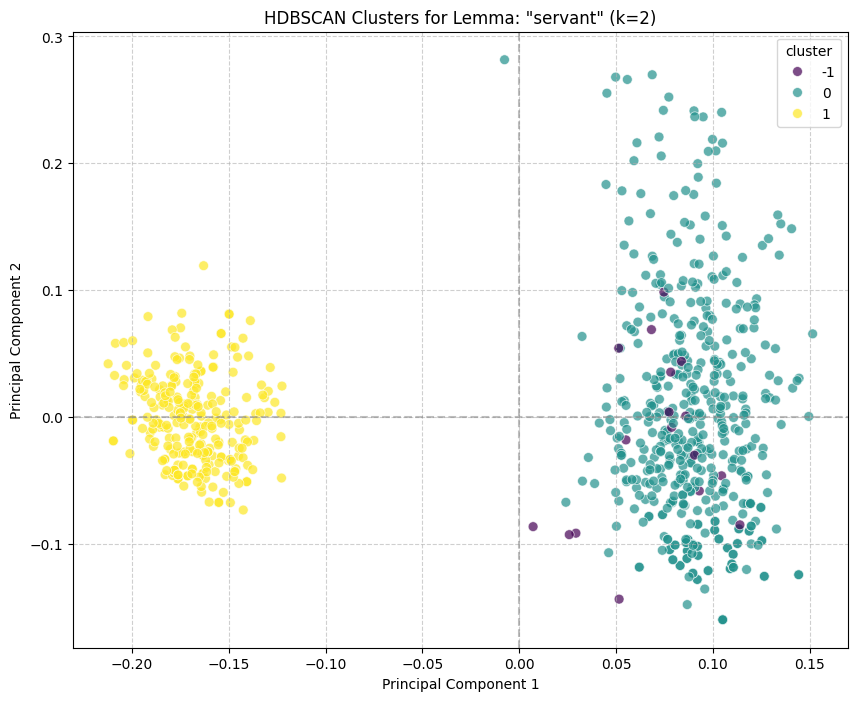

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize

# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition (copied from MqXauqA6EB77) ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels
# --- End of HDBSCAN function copy ---

# Load English embeddings and lemmas
en_embeddings_data = np.load(DATA_DIR / "english_embeddings.npz", allow_pickle=True)
en_lemmas_array = en_embeddings_data["lemmas"]
en_embeddings = en_embeddings_data["embeddings"]

lemma_to_plot = 'servant'

# Get embeddings for the specific lemma
mask = (en_lemmas_array == lemma_to_plot)
servant_embeds = en_embeddings[mask]

# Re-run induce_senses_hdbscan for 'servant' to get labels for plotting
k, labels = induce_senses_hdbscan(servant_embeds)

print(f"Lemma: '{lemma_to_plot}'")
print(f"Induced senses (k): {k}")
print(f"Number of instances: {len(servant_embeds)}")
print(f"Cluster labels (first 10): {labels[:10]}")

# Reduce dimensionality for visualization using PCA
# Only reduce if there are enough samples and dimensions
if servant_embeds.shape[0] > 1 and servant_embeds.shape[1] > 1:
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    reduced_embeddings = pca.fit_transform(servant_embeds)
else:
    print("Not enough data points or dimensions for PCA. Skipping plot.")
    reduced_embeddings = None

if reduced_embeddings is not None:
    # Create a DataFrame for plotting
    plot_df = pd.DataFrame(reduced_embeddings, columns=['PC1', 'PC2'])
    plot_df['cluster'] = labels

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1',
        y='PC2',
        hue='cluster',
        palette='viridis' if len(np.unique(labels)) > 1 else ['grey'],
        data=plot_df,
        legend='full' if len(np.unique(labels)) > 1 else False,
        s=50, # size of points
        alpha=0.7
    )
    plt.title(f'HDBSCAN Clusters for Lemma: "{lemma_to_plot}" (k={k})')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
    plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
    plt.show()

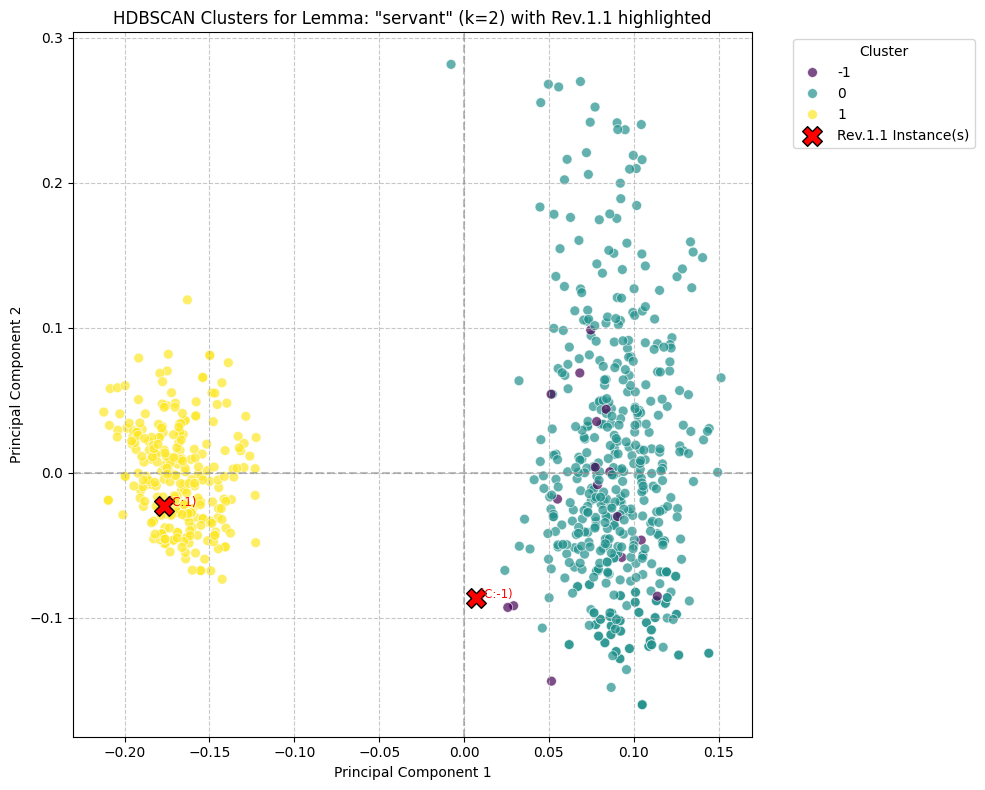

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import hdbscan
from sklearn.preprocessing import normalize

# Ensure DATA_DIR is defined
DATA_DIR = Path("/content") / "bible_data"

# --- HDBSCAN constants and function definition ---
RANDOM_STATE  = 42
LARGE_SAMPLE_SIZE = 200
COMPONENTS_UPPPER_LIMIT = 100
MIN_CLUSTER_DATA_SIZE = 6
MIN_CLUSTER_DATA_PROPORTION = 0.03
SECOND_CLUSTER_THRESHOLD = 0.08

def induce_senses_hdbscan(embeddings: np.ndarray):
    n_samples, n_features = embeddings.shape

    if n_samples < 20:
        return 1, np.zeros(n_samples, dtype=int)

    # L2 normalize
    embeddings = normalize(embeddings)

    # Optional PCA only if large sample size
    if n_samples > LARGE_SAMPLE_SIZE:
        n_components = min(COMPONENTS_UPPPER_LIMIT,
                           n_samples - 1,
                           n_features)
        embeddings = PCA(
            n_components=n_components,
            random_state=RANDOM_STATE
        ).fit_transform(embeddings)
        embeddings = normalize(embeddings)

    min_cluster_size = max(MIN_CLUSTER_DATA_SIZE,
                           int(MIN_CLUSTER_DATA_PROPORTION * n_samples))

    clusterer = hdbscan.HDBSCAN(
        metric="euclidean",
        min_cluster_size=min_cluster_size,
        min_samples=max(5, min_cluster_size // 2),
        cluster_selection_method="eom"
    )

    labels = clusterer.fit_predict(embeddings)

    clusters = set(labels)
    clusters.discard(-1)

    k = len(clusters)

    if k <= 1:
        return 1, np.zeros(n_samples, dtype=int)

    sizes = sorted([sum(labels == c) for c in clusters], reverse=True)

    if sizes[1] / n_samples < SECOND_CLUSTER_THRESHOLD:
        return 1, np.zeros(n_samples, dtype=int)

    return k, labels

# Load English embeddings and lemmas
en_embeddings_data = np.load(DATA_DIR / "english_embeddings.npz", allow_pickle=True)
en_lemmas_array = en_embeddings_data["lemmas"]
en_embeddings = en_embeddings_data["embeddings"]
en_labels = pd.read_csv(DATA_DIR / "english_sense_labels.csv") # Load en_labels here

lemma_to_plot = 'servant'

# Get embeddings for the specific lemma
mask_all_servant = (en_lemmas_array == lemma_to_plot)
servant_embeds = en_embeddings[mask_all_servant]

# Re-run induce_senses_hdbscan for 'servant' to get labels for plotting
k, labels = induce_senses_hdbscan(servant_embeds)

# Reduce dimensionality for visualization using PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
reduced_embeddings = pca.fit_transform(servant_embeds)

# Create a DataFrame for plotting all 'servant' instances
plot_df = pd.DataFrame(reduced_embeddings, columns=['PC1', 'PC2'])
plot_df['cluster'] = labels

# --- Identify Rev.1.1 instances ---
# Filter en_labels for 'servant' instances and store their original row indices
servant_full_labels = en_labels[en_labels['lemma'] == lemma_to_plot].reset_index(drop=True)

# Find the indices within servant_full_labels (and thus within servant_embeds and reduced_embeddings)
# that correspond to 'Rev.1.1'
rev1_1_local_indices = servant_full_labels[
    servant_full_labels['verse_id'] == 'Rev.1.1'
].index.tolist()

# Get the PC coordinates and cluster labels for Rev.1.1 instances
rev1_1_points = plot_df.loc[rev1_1_local_indices]

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='viridis' if len(np.unique(labels)) > 1 else ['grey'],
    data=plot_df,
    legend='full' if len(np.unique(labels)) > 1 else False,
    s=50, # size of points
    alpha=0.7
)

# Overlay Rev.1.1 points
if not rev1_1_points.empty:
    sns.scatterplot(
        x='PC1',
        y='PC2',
        data=rev1_1_points,
        marker='X', # Use a distinct marker
        s=200,      # Make it larger
        color='red', # Use a distinct color
        label='Rev.1.1 Instance(s)',
        edgecolor='black',
        linewidth=1
    )
    # Add text labels for the Rev.1.1 points if there are multiple
    for i, row in rev1_1_points.iterrows():
        plt.text(row['PC1'], row['PC2'], f' (C:{int(row["cluster"])})',
                 horizontalalignment='left', size='small', color='red')


plt.title(f'HDBSCAN Clusters for Lemma: "{lemma_to_plot}" (k={k}) with Rev.1.1 highlighted')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()